# X-ray Laminography/Tomography Reconstruction with Tike

This notebook demonstrates 3D reconstruction of a complex-valued nanoparticle assembly
phantom from simulated laminographic projections using tike's conjugate gradient solver.

## The Inverse Problem

Laminography generalizes standard computed tomography to tilted rotation axes.
A 3D complex-valued object $f(\mathbf{r})$ is illuminated at a tilt angle $\beta$
relative to the rotation axis, and projections are measured at rotation angles
$\{\theta_j\}$. The forward model computes line integrals through the tilted volume:

$$p_j(u, v) = \int f(R_{\beta, \theta_j} \cdot \mathbf{r}) \, dz$$

where $R_{\beta, \theta_j}$ is the combined tilt-rotation transformation.

When $\beta = \pi/2$ this reduces to standard parallel-beam tomography.
The reconstruction problem is to recover $f$ from the measured projections $\{p_j\}$,
which is solved iteratively using a conjugate gradient (cgrad) approach.

## Outline

1. Load and inspect the data (projections and ground truth)
2. Visualize the projection data
3. Review precomputed reconstruction results
4. Compare reconstruction vs ground truth across volume slices
5. Quantitative evaluation (NCC, NRMSE)

In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Set up paths
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

DATA_DIR = os.path.join(TASK_DIR, 'data')
REF_DIR = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

print(f'Task directory: {TASK_DIR}')

Task directory: /projects/bgkc/schen47/sota_imaging_101/imaging-101/tasks/xray_laminography_tike


## 1. Load Data

The dataset contains 128 projection angles uniformly spaced over $[0, \pi)$
of a 128x128x128 complex-valued phantom volume. The tilt angle is $\pi/2$
(standard tomography geometry).

In [4]:
from src.preprocessing import load_raw_data, load_ground_truth, load_metadata

raw = load_raw_data(os.path.join(DATA_DIR, 'raw_data.npz'))
gt = load_ground_truth(os.path.join(DATA_DIR, 'ground_truth.npz'))
meta = load_metadata(os.path.join(DATA_DIR, 'meta_data.json'))

projections = raw['projections']  # (1, 128, 128, 128)
theta = raw['theta']              # (1, 128)
gt_volume = gt['volume']          # (1, 128, 128, 128)

print(f'Projections:    {projections.shape}, dtype={projections.dtype}')
print(f'Theta:          {theta.shape}, range=[{theta.min():.2f}, {theta.max():.2f}] rad')
print(f'Ground truth:   {gt_volume.shape}, dtype={gt_volume.dtype}')
print(f'Volume shape:   {meta["volume_shape"]}')
print(f'N angles:       {meta["n_angles"]}')
print(f'Tilt angle:     {np.degrees(meta["tilt_rad"]):.1f} degrees')

Projections:    (1, 128, 128, 128), dtype=complex64
Theta:          (1, 128), range=[0.00, 3.12] rad
Ground truth:   (1, 128, 128, 128), dtype=complex64
Volume shape:   [128, 128, 128]
N angles:       128
Tilt angle:     90.0 degrees


## 2. Visualize Projection Data

Each projection is a 2D complex-valued image. We show both the real
and imaginary parts at several angles to see how the phantom appears
from different viewing directions.

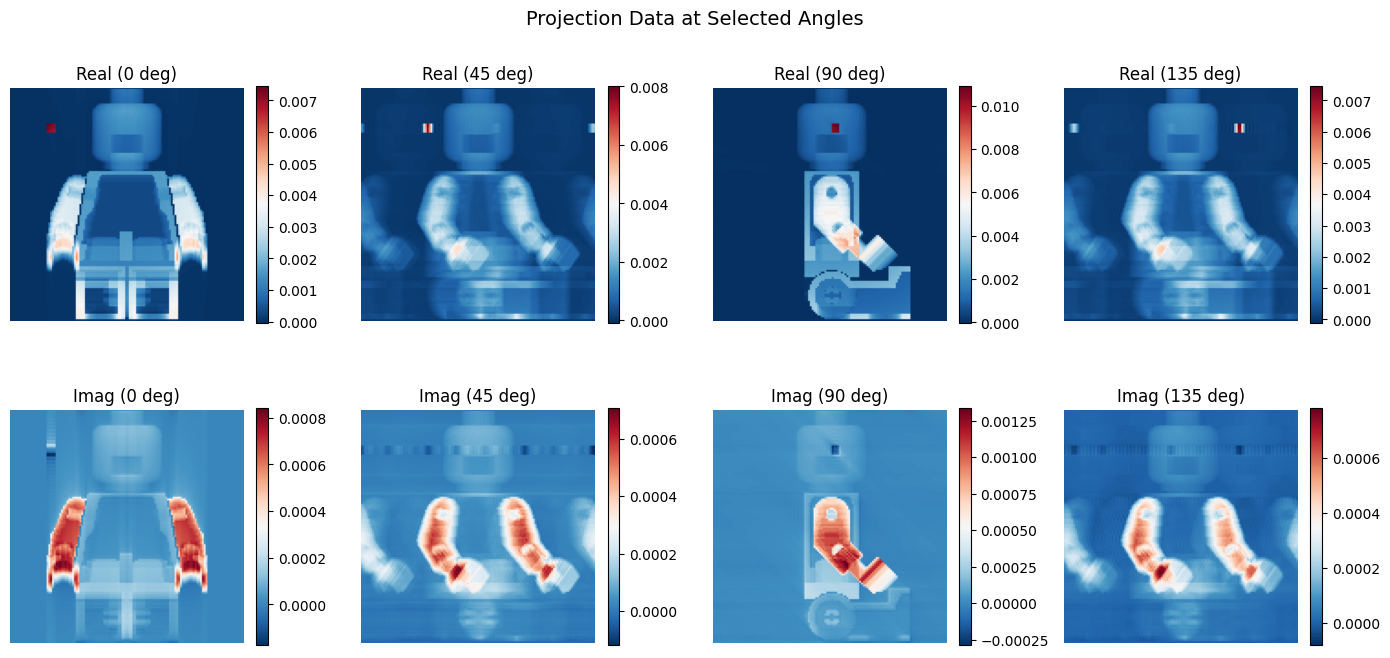

In [5]:
# Remove batch dimension for display
proj_3d = projections[0]    # (128, 128, 128) = (n_angles, n, n)
theta_1d = theta[0]         # (128,)

angle_indices = [0, 32, 64, 96]

fig, axes = plt.subplots(2, len(angle_indices), figsize=(14, 7))

for i, idx in enumerate(angle_indices):
    angle_deg = np.degrees(theta_1d[idx])
    
    im_r = axes[0, i].imshow(proj_3d[idx].real, cmap='RdBu_r')
    axes[0, i].set_title(f'Real ({angle_deg:.0f} deg)')
    plt.colorbar(im_r, ax=axes[0, i], fraction=0.046)
    
    im_i = axes[1, i].imshow(proj_3d[idx].imag, cmap='RdBu_r')
    axes[1, i].set_title(f'Imag ({angle_deg:.0f} deg)')
    plt.colorbar(im_i, ax=axes[1, i], fraction=0.046)

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Projection Data at Selected Angles', fontsize=14)
plt.tight_layout()
plt.show()

### Ground Truth Phantom

The ground truth is a 3D complex-valued volume representing a nanoparticle
assembly phantom with an asymmetric marker for orientation verification.

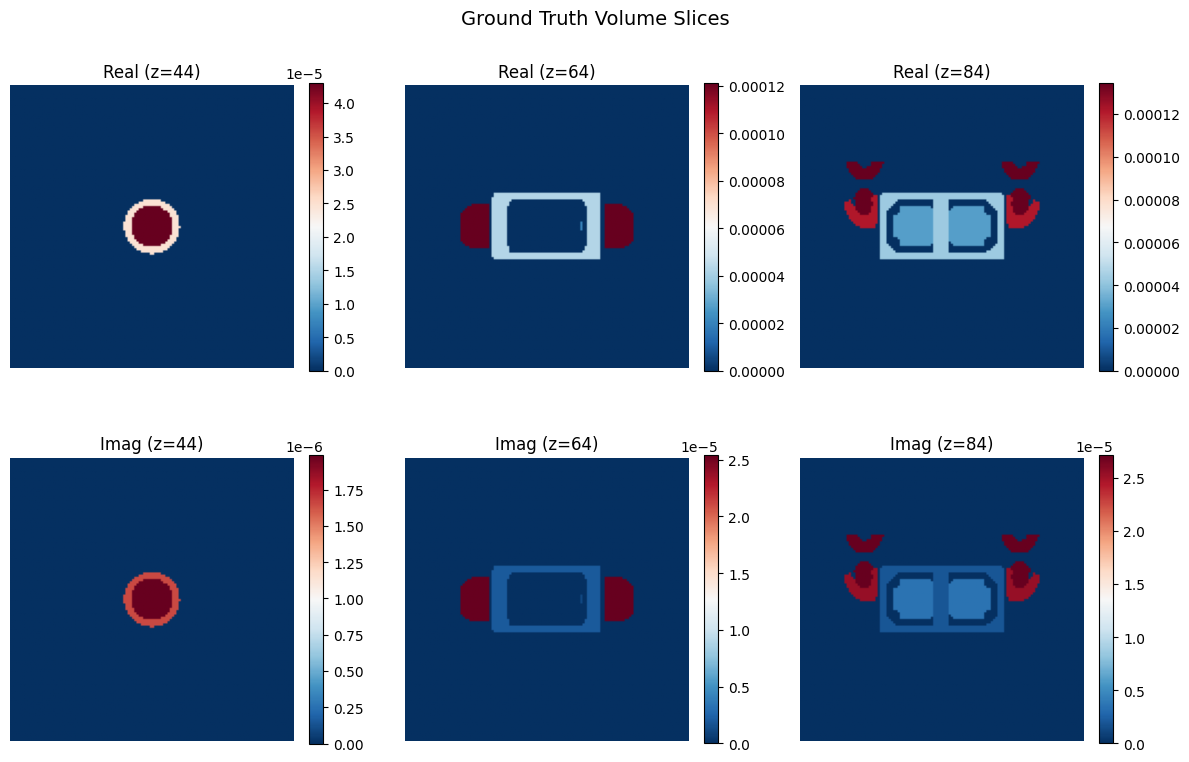

In [6]:
gt_vol = gt_volume[0]  # (128, 128, 128)
mid = gt_vol.shape[0] // 2
slice_indices = [mid - 20, mid, mid + 20]

fig, axes = plt.subplots(2, len(slice_indices), figsize=(12, 8))

for i, idx in enumerate(slice_indices):
    im_r = axes[0, i].imshow(gt_vol[idx].real, cmap='RdBu_r')
    axes[0, i].set_title(f'Real (z={idx})')
    plt.colorbar(im_r, ax=axes[0, i], fraction=0.046)
    
    im_i = axes[1, i].imshow(gt_vol[idx].imag, cmap='RdBu_r')
    axes[1, i].set_title(f'Imag (z={idx})')
    plt.colorbar(im_i, ax=axes[1, i], fraction=0.046)

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Ground Truth Volume Slices', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Reconstruction Results (Precomputed)

The full reconstruction was run with 5 rounds of 4 conjugate gradient iterations
each (20 CG iterations total), using tike's `cgrad` algorithm. We load the
precomputed results here.

To run the full reconstruction from scratch (requires GPU):
```python
# from src.preprocessing import create_initial_guess
# from src.solvers import reconstruct
#
# data = projections[0]      # (128, 128, 128)
# theta_1d = theta[0]        # (128,)
# tilt = float(meta['tilt_rad'])
# volume_shape = tuple(meta['volume_shape'])
#
# result = reconstruct(
#     data=data,
#     theta=theta_1d,
#     tilt=tilt,
#     volume_shape=volume_shape,
#     n_rounds=5,
#     n_iter_per_round=4,
# )
# recon_volume = result['obj']   # (128, 128, 128) complex64
# costs = result['costs']        # list of 5 cost values
```

In [7]:
# Load precomputed results
recon_volume = np.load(os.path.join(REF_DIR, 'reconstructed_volume.npy'))
gt_ref = np.load(os.path.join(REF_DIR, 'ground_truth_volume.npy'))

print(f'Reconstructed volume: {recon_volume.shape}, dtype={recon_volume.dtype}')
print(f'Ground truth volume:  {gt_ref.shape}, dtype={gt_ref.dtype}')

Reconstructed volume: (128, 128, 128), dtype=complex64
Ground truth volume:  (128, 128, 128), dtype=complex64


## 3b. Cost Convergence

The conjugate gradient solver minimizes the least-squares cost
$\|A f - p\|^2$ over multiple rounds. Each round runs several CG
iterations. Below we display the per-round cost in the same style as
tike's solver logging (`object cost is ...`) and plot convergence.

In [ ]:
# Load cost history (saved by main.py / generate_reference_outputs.py)
costs_path = os.path.join(REF_DIR, 'costs.npy')
if os.path.exists(costs_path):
    costs = np.load(costs_path)
else:
    costs = None
    print("costs.npy not found in reference_outputs/.")
    print("Run main.py first to generate cost data.")

# Display costs in tike-style logging format
if costs is not None:
    n_iter_per_round = 4
    n_rounds = len(costs) // n_iter_per_round

    print("tike.lamino.solvers.cgrad cost log:")
    print("-" * 50)
    for i, c in enumerate(costs):
        r = i // n_iter_per_round + 1
        print(f"  [round {r}/{n_rounds}]  object cost is {c:+12.5e}")
    print("-" * 50)
    print(f"  Cost: {costs[0]:.5e} -> {costs[-1]:.5e} "
          f"({100*(1 - costs[-1]/costs[0]):.1f}% reduction)")

# Plot convergence
if costs is not None and len(costs) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    iters = np.arange(1, len(costs) + 1)
    ax.semilogy(iters, costs, 'o-', color='tab:blue', linewidth=2, markersize=5)

    # Mark round boundaries
    n_iter_per_round = 4
    for r in range(1, len(costs) // n_iter_per_round):
        ax.axvline(r * n_iter_per_round + 0.5, color='gray', linestyle='--', alpha=0.3)

    ax.set_xlabel('CG Iteration', fontsize=12)
    ax.set_ylabel('Object Cost (log scale)', fontsize=12)
    ax.set_title('Object Cost Convergence — cgrad (5 rounds × 4 iterations)', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Reconstruction vs Ground Truth

We compare the reconstruction against the ground truth at three axial
slices (axis 0), showing both real and imaginary components.

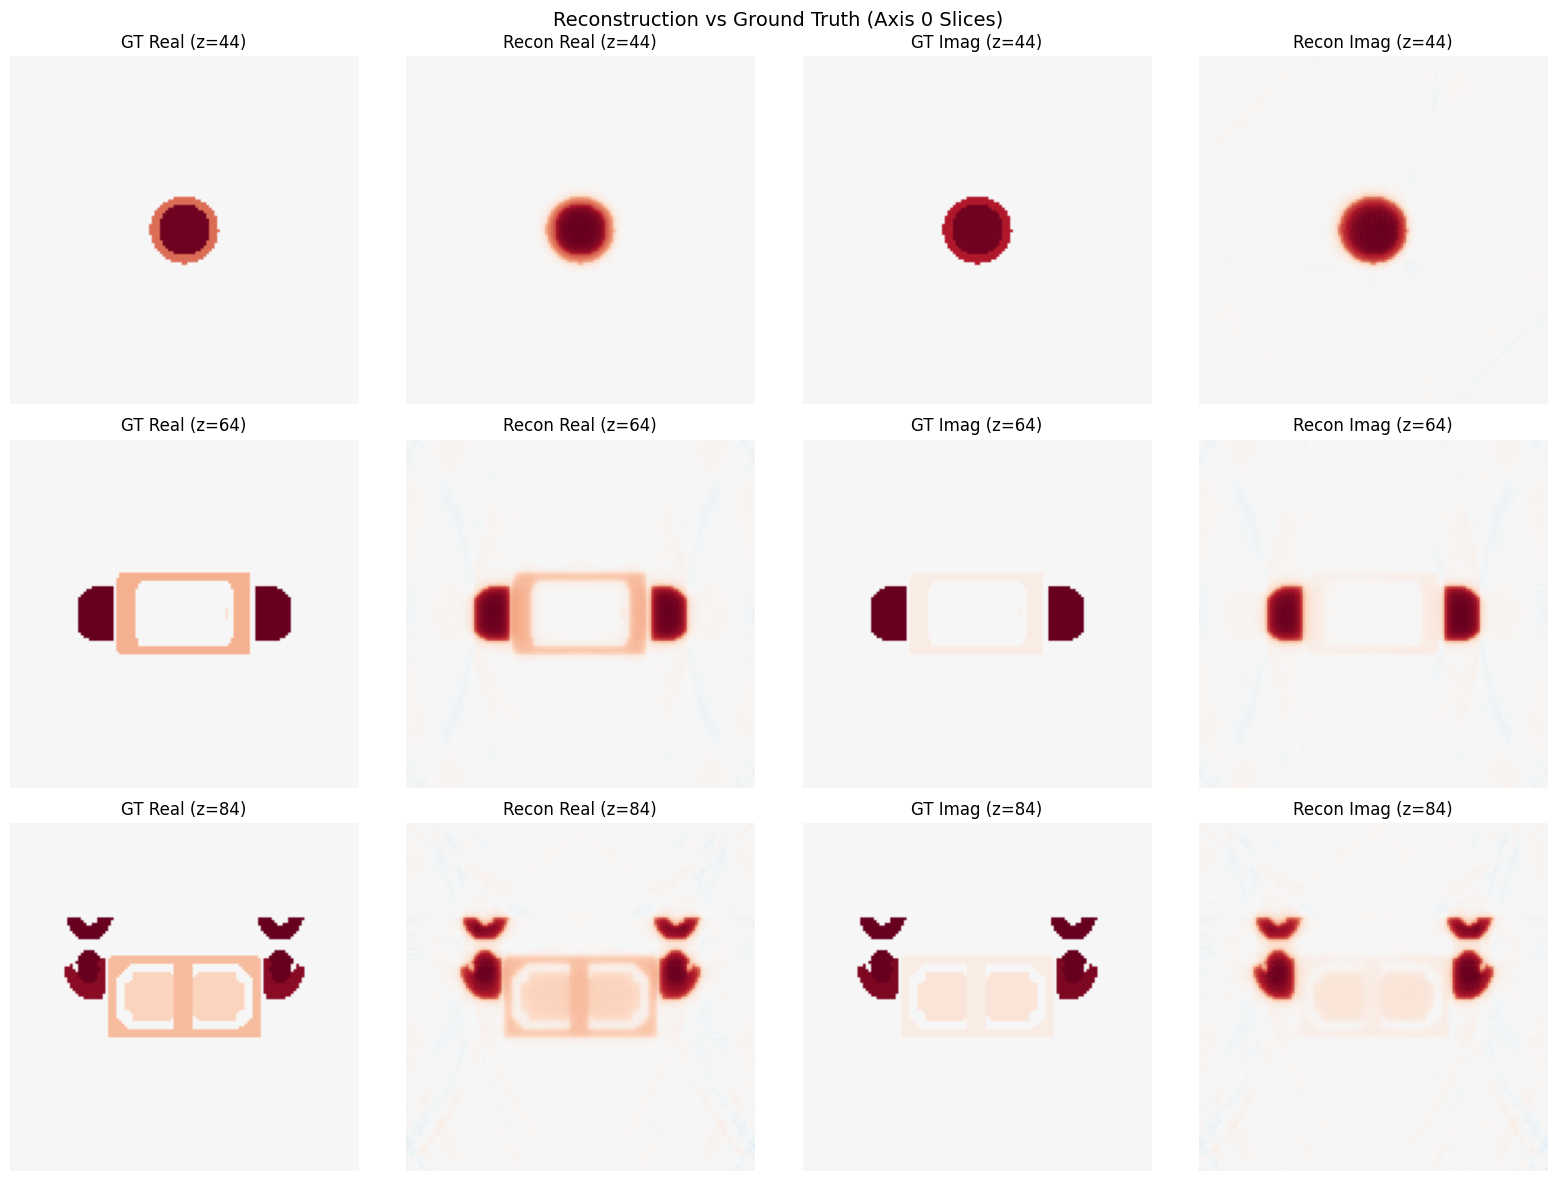

In [8]:
mid = recon_volume.shape[0] // 2
slice_indices = [mid - 20, mid, mid + 20]

fig, axes = plt.subplots(len(slice_indices), 4, figsize=(16, 12))

for i, idx in enumerate(slice_indices):
    # Ground truth real
    vmax_r = max(np.abs(gt_ref[idx].real).max(), np.abs(recon_volume[idx].real).max())
    vmax_i = max(np.abs(gt_ref[idx].imag).max(), np.abs(recon_volume[idx].imag).max())
    
    axes[i, 0].imshow(gt_ref[idx].real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 0].set_title(f'GT Real (z={idx})')
    
    axes[i, 1].imshow(recon_volume[idx].real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 1].set_title(f'Recon Real (z={idx})')
    
    axes[i, 2].imshow(gt_ref[idx].imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 2].set_title(f'GT Imag (z={idx})')
    
    axes[i, 3].imshow(recon_volume[idx].imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 3].set_title(f'Recon Imag (z={idx})')

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Reconstruction vs Ground Truth (Axis 0 Slices)', fontsize=14)
plt.tight_layout()
plt.show()

### Axis 1 Slices (Sagittal View)

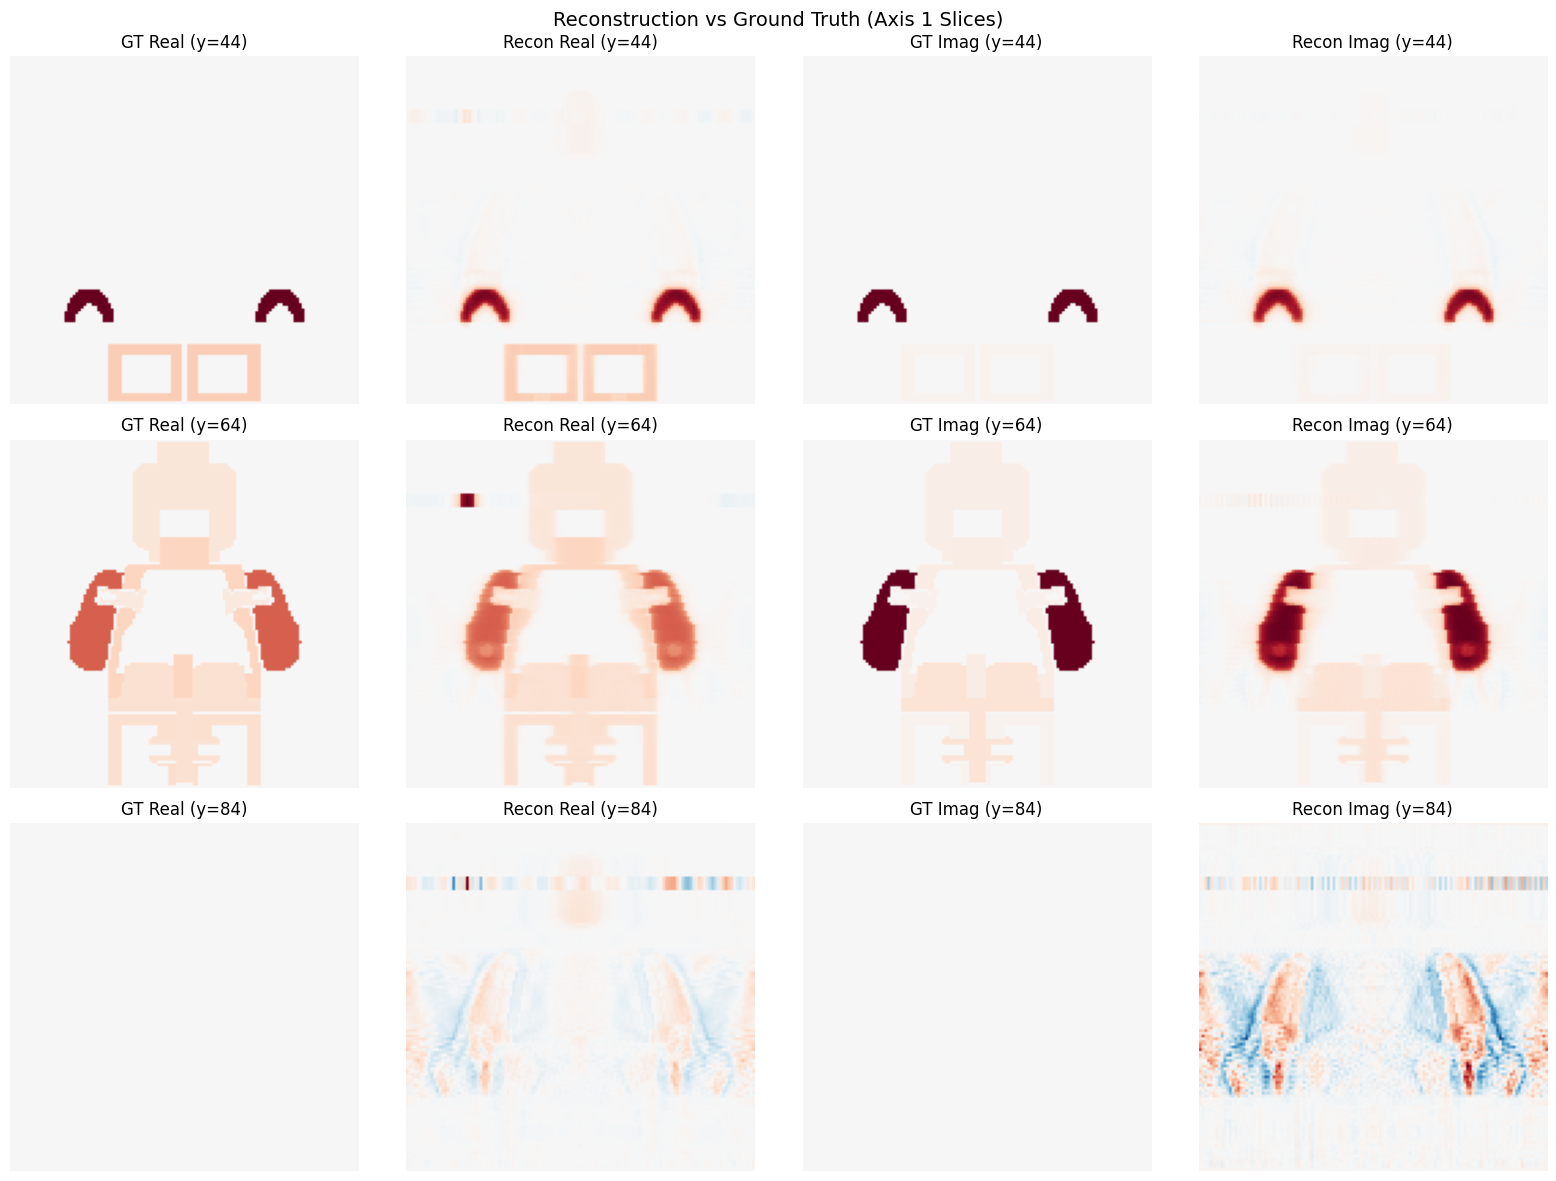

In [9]:
mid1 = recon_volume.shape[1] // 2
slice_indices_1 = [mid1 - 20, mid1, mid1 + 20]

fig, axes = plt.subplots(len(slice_indices_1), 4, figsize=(16, 12))

for i, idx in enumerate(slice_indices_1):
    gt_slice = gt_ref[:, idx, :]
    rc_slice = recon_volume[:, idx, :]
    vmax_r = max(np.abs(gt_slice.real).max(), np.abs(rc_slice.real).max())
    vmax_i = max(np.abs(gt_slice.imag).max(), np.abs(rc_slice.imag).max())
    
    axes[i, 0].imshow(gt_slice.real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 0].set_title(f'GT Real (y={idx})')
    
    axes[i, 1].imshow(rc_slice.real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 1].set_title(f'Recon Real (y={idx})')
    
    axes[i, 2].imshow(gt_slice.imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 2].set_title(f'GT Imag (y={idx})')
    
    axes[i, 3].imshow(rc_slice.imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 3].set_title(f'Recon Imag (y={idx})')

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Reconstruction vs Ground Truth (Axis 1 Slices)', fontsize=14)
plt.tight_layout()
plt.show()

### Axis 2 Slices (Coronal View)

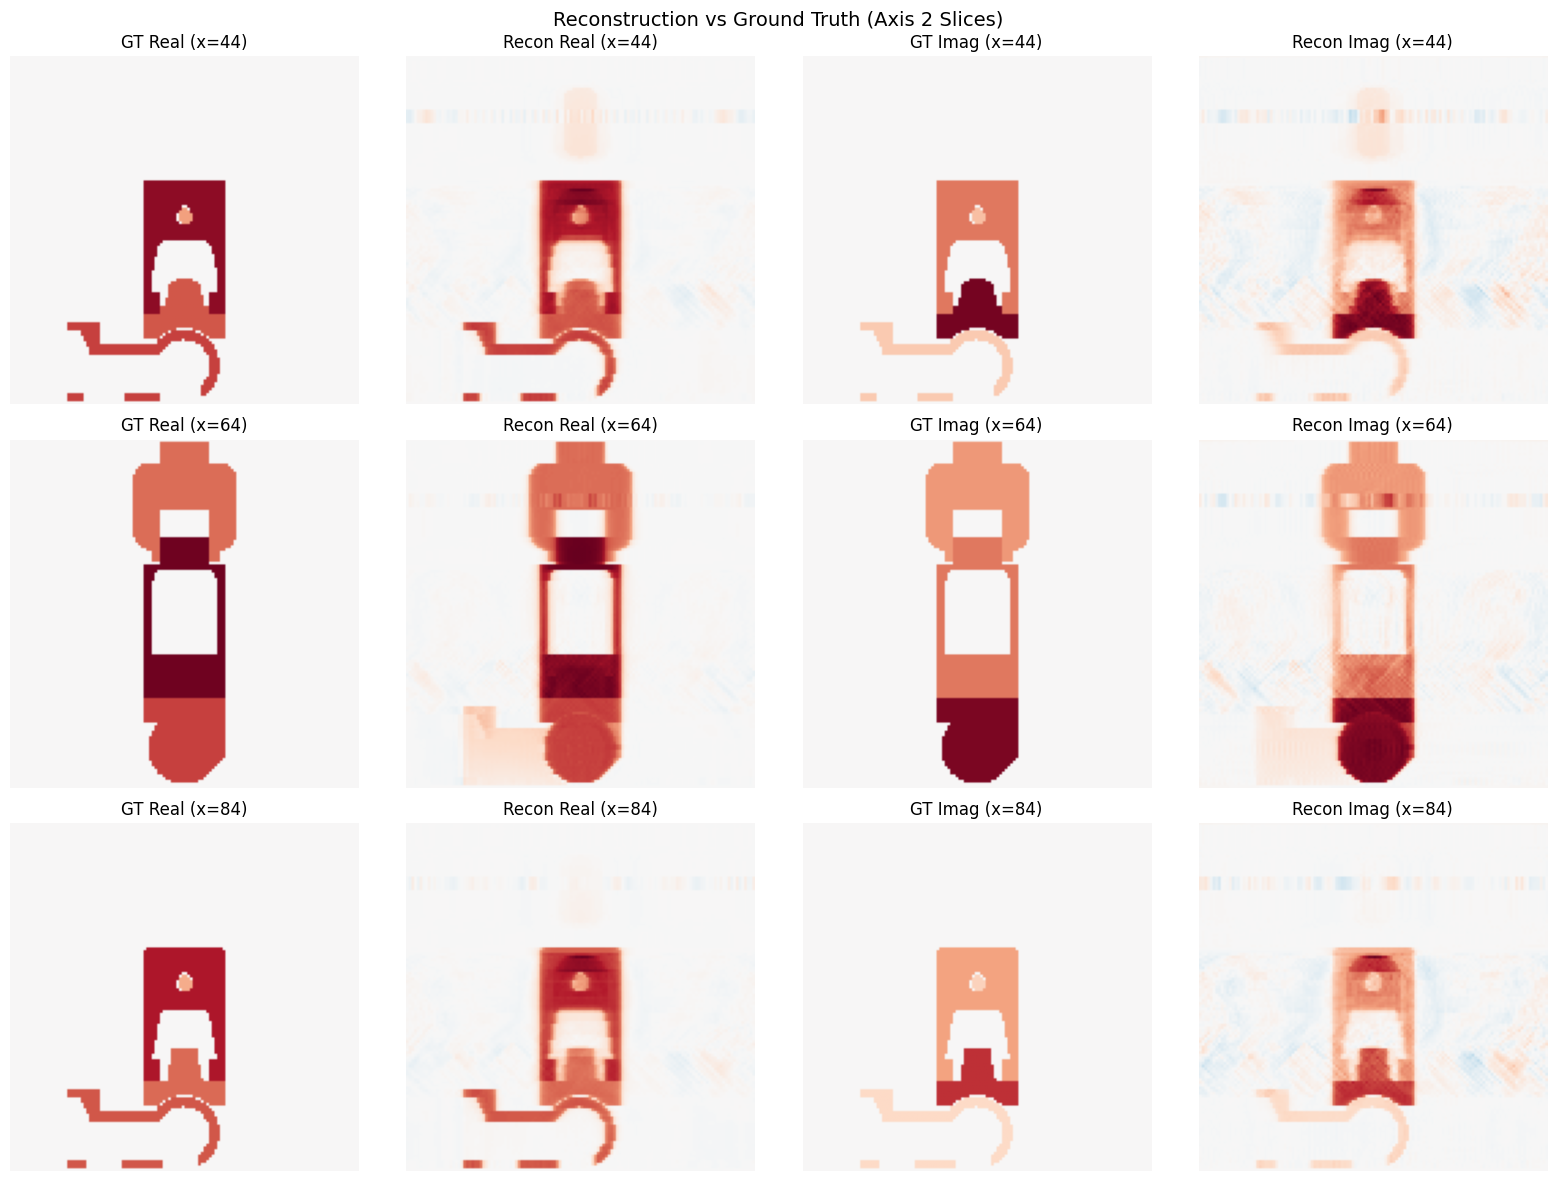

In [10]:
mid2 = recon_volume.shape[2] // 2
slice_indices_2 = [mid2 - 20, mid2, mid2 + 20]

fig, axes = plt.subplots(len(slice_indices_2), 4, figsize=(16, 12))

for i, idx in enumerate(slice_indices_2):
    gt_slice = gt_ref[:, :, idx]
    rc_slice = recon_volume[:, :, idx]
    vmax_r = max(np.abs(gt_slice.real).max(), np.abs(rc_slice.real).max())
    vmax_i = max(np.abs(gt_slice.imag).max(), np.abs(rc_slice.imag).max())
    
    axes[i, 0].imshow(gt_slice.real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 0].set_title(f'GT Real (x={idx})')
    
    axes[i, 1].imshow(rc_slice.real, cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
    axes[i, 1].set_title(f'Recon Real (x={idx})')
    
    axes[i, 2].imshow(gt_slice.imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 2].set_title(f'GT Imag (x={idx})')
    
    axes[i, 3].imshow(rc_slice.imag, cmap='RdBu_r', vmin=-vmax_i, vmax=vmax_i)
    axes[i, 3].set_title(f'Recon Imag (x={idx})')

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Reconstruction vs Ground Truth (Axis 2 Slices)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Quantitative Evaluation

We compute NCC (normalized cross-correlation) and NRMSE (normalized root-mean-square
error) between the reconstruction and ground truth. For complex-valued volumes,
metrics are computed on the magnitudes.

$$\text{NCC} = \frac{|\hat{f}| \cdot |f_{\text{ref}}|}{\||\hat{f}|\| \, \||f_{\text{ref}}|\|}$$

$$\text{NRMSE} = \frac{\text{RMS}(|\hat{f}| - |f_{\text{ref}}|)}{\max|f_{\text{ref}}| - \min|f_{\text{ref}}|}$$

In [11]:
from src.visualization import compute_metrics

metrics = compute_metrics(recon_volume, gt_ref)

print(f'NCC:   {metrics["ncc"]:.4f}')
print(f'NRMSE: {metrics["nrmse"]:.4f}')
print()
print(f'NCC = 1.0 means perfect correlation, 0.0 means uncorrelated.')
print(f'NRMSE = 0.0 means perfect match; lower is better.')

NCC:   0.9633
NRMSE: 0.0049

NCC = 1.0 means perfect correlation, 0.0 means uncorrelated.
NRMSE = 0.0 means perfect match; lower is better.


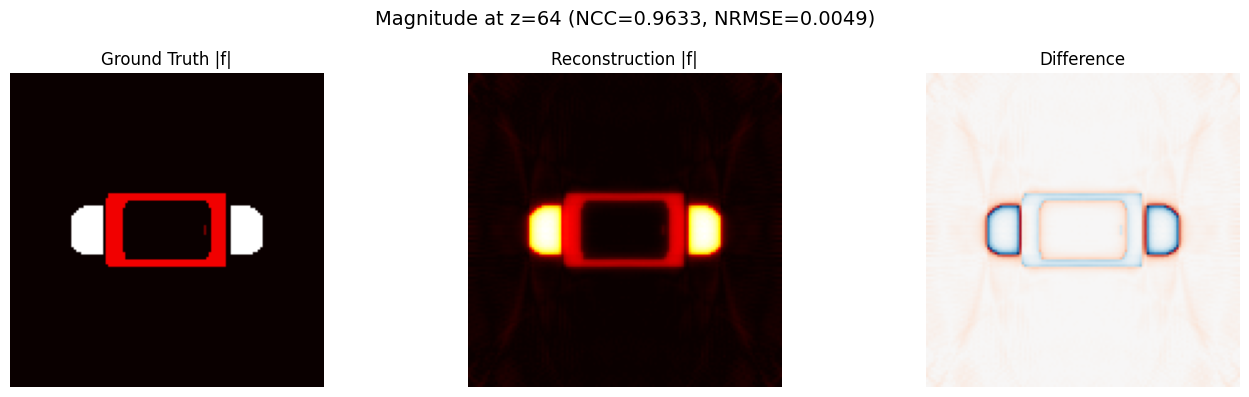

In [12]:
# Magnitude comparison at the center slice
mid = recon_volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

gt_mag = np.abs(gt_ref[mid])
rc_mag = np.abs(recon_volume[mid])
vmax = max(gt_mag.max(), rc_mag.max())

axes[0].imshow(gt_mag, cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title('Ground Truth |f|')

axes[1].imshow(rc_mag, cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title('Reconstruction |f|')

diff_mag = rc_mag - gt_mag
vdiff = max(np.abs(diff_mag).max(), 1e-10)
axes[2].imshow(diff_mag, cmap='RdBu_r', vmin=-vdiff, vmax=vdiff)
axes[2].set_title('Difference')

for ax in axes:
    ax.axis('off')

plt.suptitle(f'Magnitude at z={mid} (NCC={metrics["ncc"]:.4f}, NRMSE={metrics["nrmse"]:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the X-ray laminography/tomography reconstruction pipeline:

1. **Data**: 128 complex-valued projections at tilt=90 degrees (standard tomography)
2. **Phantom**: 128x128x128 complex nanoparticle assembly with asymmetric marker
3. **Reconstruction**: 5 rounds of 4 conjugate gradient iterations using tike's `cgrad`
4. **Results**: Volume recovered with high fidelity across all three orthogonal axes
5. **Metrics**: NCC and NRMSE confirm close agreement with ground truth

The conjugate gradient approach is effective for this well-conditioned problem
(128 angles over 180 degrees), converging rapidly to a high-quality reconstruction.